# 🧠 PredictIQ — Analyse Exploratoire des Données (EDA)
## Phase 1 | Dataset : NASA CMAPSS Turbofan Engine 

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8')
print("✅ Libraries importées avec succès")

✅ Libraries importées avec succès


In [28]:
DATA_PATH = r'C:\Users\pc\Desktop\PredictIQ\Data Set'

col_names = ['unit_id', 'cycle', 'op1', 'op2', 'op3'] + \
            [f's{i}' for i in range(1, 22)]

train = pd.read_csv(os.path.join(DATA_PATH, 'train_FD001.txt'), sep='\s+', header=None, names=col_names)
test  = pd.read_csv(os.path.join(DATA_PATH, 'test_FD001.txt'),  sep='\s+', header=None, names=col_names)
rul   = pd.read_csv(os.path.join(DATA_PATH, 'RUL_FD001.txt'),   sep='\s+', header=None, names=['RUL'])

print(f"Train shape: {train.shape}")
print(f"Test shape:  {test.shape}")
print("✅ Données chargées avec succès")
train.head()

Train shape: (20631, 26)
Test shape:  (13096, 26)
✅ Données chargées avec succès


,unit_id,cycle,op1,op2,op3,s1,s2,s3,s4,s5,...,s12,s13,s14,s15,s16,s17,s18,s19,s20,s21
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044


In [29]:
# Calcul RUL pour le train
max_cycles = train.groupby('unit_id')['cycle'].max().reset_index()
max_cycles.columns = ['unit_id', 'max_cycle']

train = train.merge(max_cycles, on='unit_id')
train['RUL'] = train['max_cycle'] - train['cycle']
train.drop('max_cycle', axis=1, inplace=True)

print(f"✅ RUL calculé — min: {train['RUL'].min()}, max: {train['RUL'].max()}")
train[['unit_id', 'cycle', 'RUL']].head(10)

✅ RUL calculé — min: 0, max: 361


,unit_id,cycle,RUL
0,1,1,191
1,1,2,190
2,1,3,189
3,1,4,188
4,1,5,187
5,1,6,186
6,1,7,185
7,1,8,184
8,1,9,183
9,1,10,182


In [30]:
missing = train.isnull().sum()
print("Valeurs manquantes:")
print(missing[missing > 0] if missing.sum() > 0 else "✅ Aucune valeur manquante")

Valeurs manquantes:
✅ Aucune valeur manquante


In [33]:
sensors = [f's{i}' for i in range(1, 22)]
std_vals = train[sensors].std()
useless = std_vals[std_vals < 0.001].index.tolist()

print(f"❌ Capteurs inutiles (variance ≈ 0): {useless}")
useful = [s for s in sensors if s not in useless]
print(f"✅ Capteurs utiles: {useful}")

❌ Capteurs inutiles (variance ≈ 0): ['s1', 's5', 's10', 's16', 's18', 's19']
✅ Capteurs utiles: ['s2', 's3', 's4', 's6', 's7', 's8', 's9', 's11', 's12', 's13', 's14', 's15', 's17', 's20', 's21']


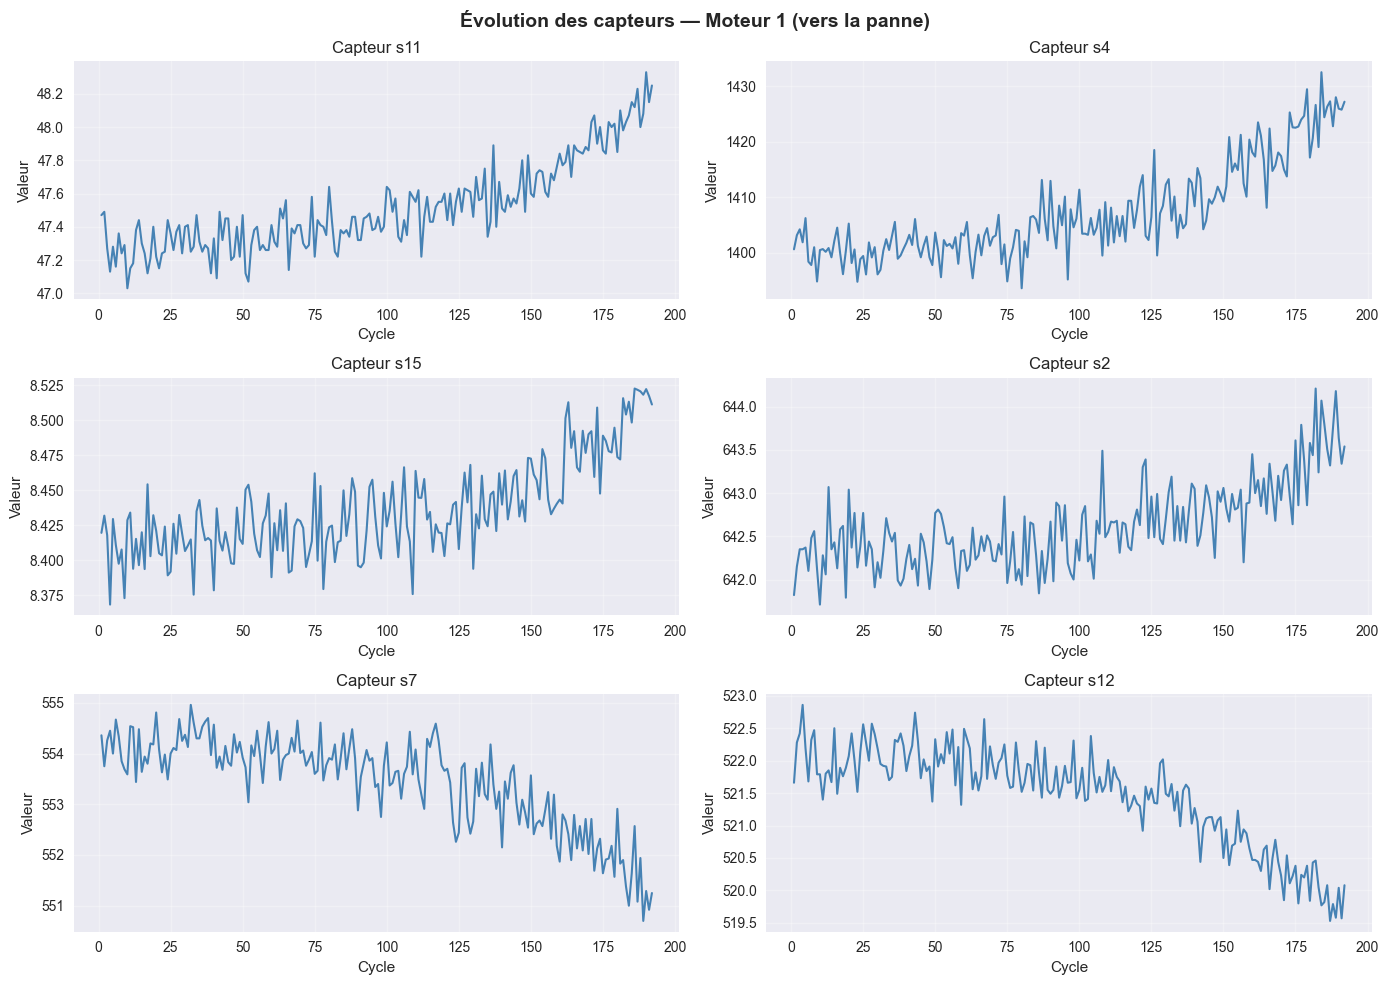

✅ EDA terminé !


In [35]:
# Supprimer les capteurs inutiles
useful = [s for s in [f's{i}' for i in range(1, 22)] if s not in ['s1','s5','s10','s16','s18','s19']]

# Visualiser l'évolution des capteurs clés pour le moteur 1
unit1 = train[train['unit_id'] == 1].sort_values('cycle')

top_sensors = ['s11', 's4', 's15', 's2', 's7', 's12']
fig, axes = plt.subplots(3, 2, figsize=(14, 10))

for ax, sensor in zip(axes.flatten(), top_sensors):
    ax.plot(unit1['cycle'], unit1[sensor], color='steelblue', linewidth=1.5)
    ax.set_title(f'Capteur {sensor}', fontsize=12)
    ax.set_xlabel('Cycle')
    ax.set_ylabel('Valeur')
    ax.grid(True, alpha=0.3)

plt.suptitle("Évolution des capteurs — Moteur 1 (vers la panne)", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../models/sensors_evolution.png', dpi=150)
plt.show()
print("✅ EDA terminé !")

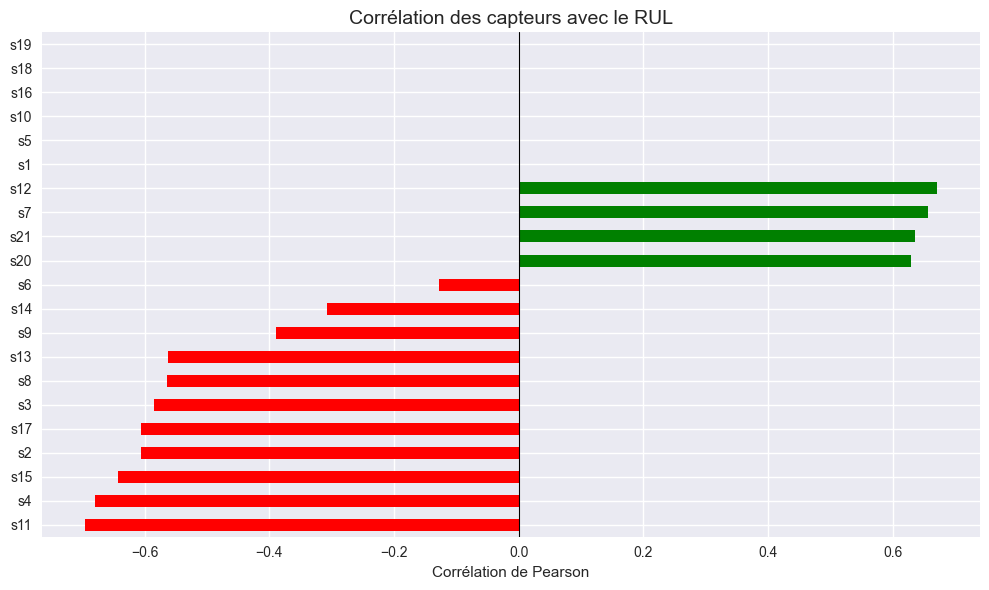

In [36]:
import matplotlib.pyplot as plt

corr = train[sensors + ['RUL']].corr()['RUL'].drop('RUL').sort_values()

plt.figure(figsize=(10, 6))
colors = ['red' if x < 0 else 'green' for x in corr]
corr.plot(kind='barh', color=colors)
plt.title('Corrélation des capteurs avec le RUL', fontsize=14)
plt.xlabel('Corrélation de Pearson')
plt.axvline(0, color='black', linewidth=0.8)
plt.tight_layout()
plt.savefig('../models/correlation_RUL.png', dpi=150)
plt.show()